In [91]:
import numpy as np
import matplotlib.pyplot as plt
from regpy.operators import CoordinateProjection 
from regpy.operators.convolution import ConvolutionOperator, GaussianBlur
from regpy.vecsps import UniformGridFcts
from regpy.solvers import RegularizationSetting
from regpy.solvers.linear.tikhonov import TikhonovCG
from regpy.solvers.linear.landweber import Landweber
from regpy.hilbert import L2, HmDomain
import regpy.stoprules as rules
from regpy.operators import SciPyLinearOperator
from scipy.sparse.linalg import eigsh

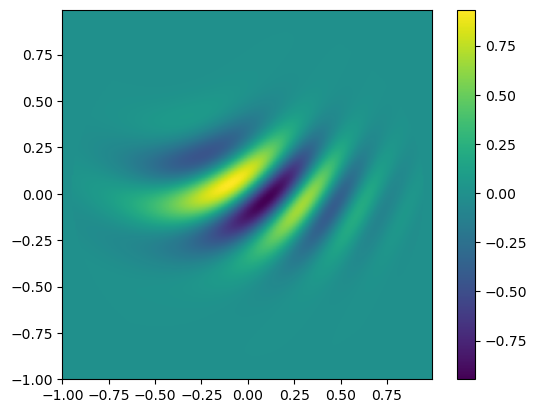

In [141]:
grid = UniformGridFcts((-1, 1, 256), (-1, 1, 256),dtype = float, periodic = True)
X = grid.coords[0]; Y = grid.coords[1]
cross = 1.0*np.logical_or((abs(X)<0.01) * (abs(Y)<0.3),(abs(X)<0.3) * (abs(Y)<0.01)) 
rad = np.sqrt(grid.coords[0]**2 + grid.coords[1]**2)
ring = 1.0*np.logical_and(rad>=0.9, rad<=0.95)
smallbox = (abs(X-0.55)<=0.05) * (abs(Y-0.55)<=0.05)

hills = np.exp(-(X/0.3)**2 - (Y/0.5)**2) * np.sin(12*X-10*(Y+Y**2))*(rad<=0.95) 

#exact_sol = ring + 2.0*cross + 1.5*smallbox
exact_sol = hills
 

extent = [grid.axes[0][0],grid.axes[0][-1], grid.axes[1][0], grid.axes[1][-1]]
plt.imshow(exact_sol,extent= extent,origin='lower');plt.colorbar()


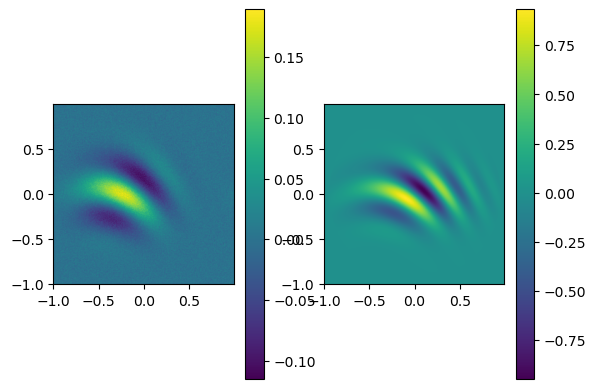

In [142]:
a=0.2
conv = GaussianBlur(grid,a)

blur = conv(exact_sol)
noise = grid.randn()
noise_level = 0.2
data = blur + (noise_level *np.linalg.norm(blur[:])/np.linalg.norm(noise[:]))* noise
#plt.imshow(np.real(exact_sol))
fig, (ax1,ax2) = plt.subplots(1,2)
im1= ax1.imshow(np.real(data[:,:]),extent=extent); plt.colorbar(im1)
im2= ax2.imshow(exact_sol,extent=extent); plt.colorbar(im2)

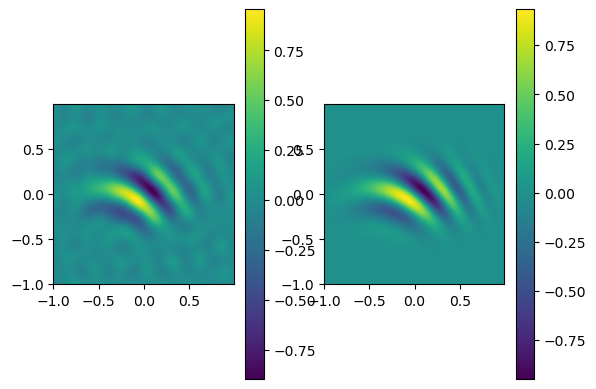

In [144]:
alpha = 1e-5
otf = conv.fourier_multiplier
reco_op= ConvolutionOperator(grid, np.conj(otf)/(np.abs(otf)**2+alpha))
reco = reco_op(data)
fig, (ax1,ax2) = plt.subplots(1,2)
im1= ax1.imshow(reco,extent=extent); plt.colorbar(im1)
im2= ax2.imshow(exact_sol,extent=extent); plt.colorbar(im2)



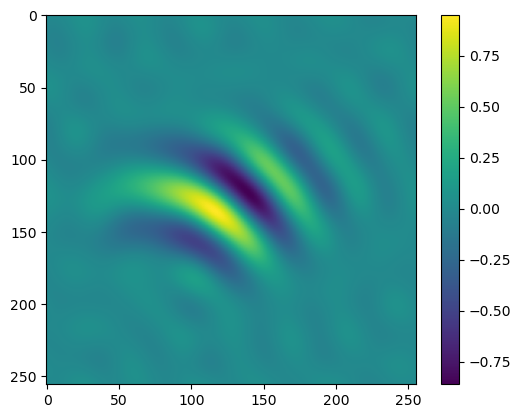

In [145]:
setting = RegularizationSetting(op=conv, penalty=L2, data_fid=L2)
solver = TikhonovCG(setting, data, regpar=alpha/256)
#solver = Landweber(setting, data,grid.zeros())
stoprule = rules.CountIterations(max_iterations=200)
reco, reco_data = solver.run(stoprule)
plt.imshow(np.real(reco)); plt.colorbar()


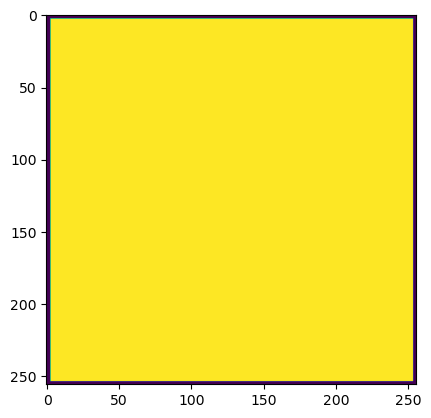

In [146]:
largebox = np.logical_and(abs(X)<=0.98,(abs(Y)<=0.98))
plt.imshow(largebox)
emb = CoordinateProjection(grid,largebox).adjoint

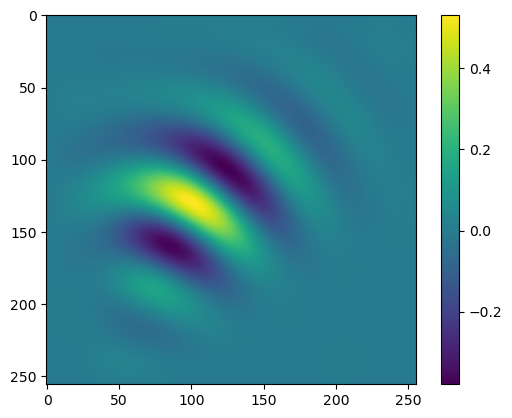

In [147]:
alpha = 1e-8
pen = HmDomain(grid, largebox, index = 3)
setting = RegularizationSetting(op=conv*emb, penalty=pen, data_fid=L2)
solver = TikhonovCG(setting, data,alpha/256,reltolx=0.001, reltoly=0.001,tol=1e-8)
stoprule = rules.CountIterations(max_iterations=1000)
reco, reco_data = solver.run(stoprule)
plt.imshow(np.real(emb(reco))); plt.colorbar()
